### Libraries

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

### Model Results

In [ ]:
#Load metadata and model
base_dir = Path("..") 
models_dir = base_dir / "transformed_data" / "combined_station_groups_1km" / "models"

with open(models_dir / "next_month_catboost_grouped_bike_1km_metadata.json") as f:
    metadata = json.load(f)

with open(base_dir / "transformed_data" / "model_outputs" / "optuna_catboost_1km_best_metrics.json") as f:
    metrics = json.load(f)

model = CatBoostClassifier()
model.load_model(models_dir / "next_month_catboost_grouped_bike_1km.cbm")

# Load Dataset
df = pd.read_csv(base_dir / "transformed_data" / "combined_station_groups_1km" / "outputs" / "station_group_month_bike_crash_dataset_1km_next_month.csv")

print(f"Dataset shape: {df.shape}")
print(f"Threshold: {metadata['threshold']}")
print(f"Test ROC AUC: {metrics['test_metrics']['roc_auc']:.4f}")
print(f"Test F1: {metrics['test_metrics']['f1']:.4f}")

Dataset shape: (2992, 133)
Threshold: 0.32
Test ROC AUC: 0.7736
Test F1: 0.5976


In [6]:
#Metrics table
validation = metrics["validation_metrics"]
test = metrics["test_metrics"]

summary = pd.DataFrame({
    "Validation": [validation["roc_auc"], validation["f1"], 
                   validation["recall"], validation["precision"], validation["accuracy"]],
    "Test": [test["roc_auc"], test["f1"], 
             test["recall"], test["precision"], test["accuracy"]]
}, index=["ROC AUC", "F1", "Recall", "Precision", "Accuracy"])

print(summary.round(4))

           Validation    Test
ROC AUC        0.7800  0.7736
F1             0.5814  0.5976
Recall         0.8222  0.6667
Precision      0.4497  0.5415
Accuracy       0.6504  0.7294


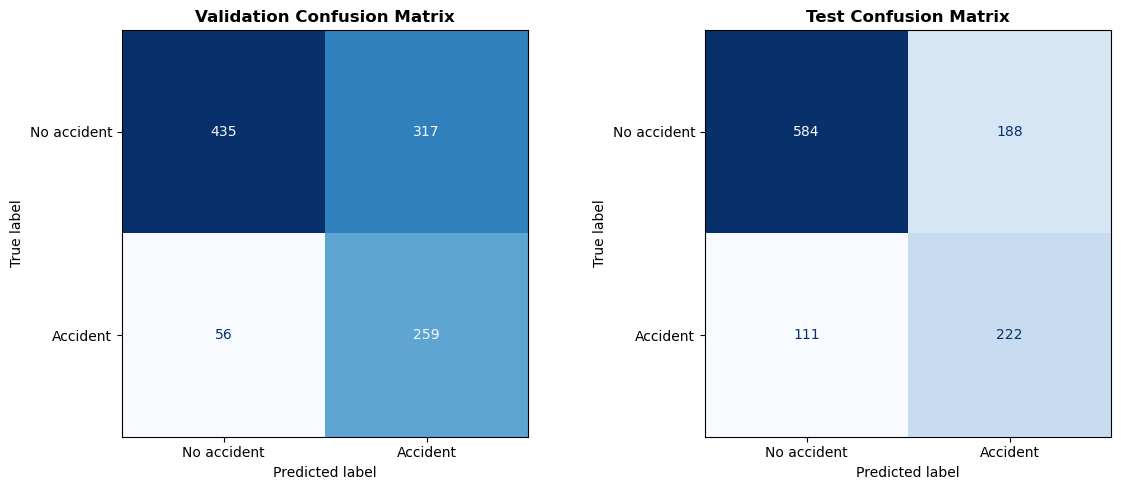

In [7]:
#Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, split, title in zip(axes, 
                             [validation, test], 
                             ["Validation", "Test"]):
    cm = split["confusion_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=np.array(cm),
                                  display_labels=["No accident", "Accident"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{title} Confusion Matrix", fontweight="bold")

plt.tight_layout()
plt.show()

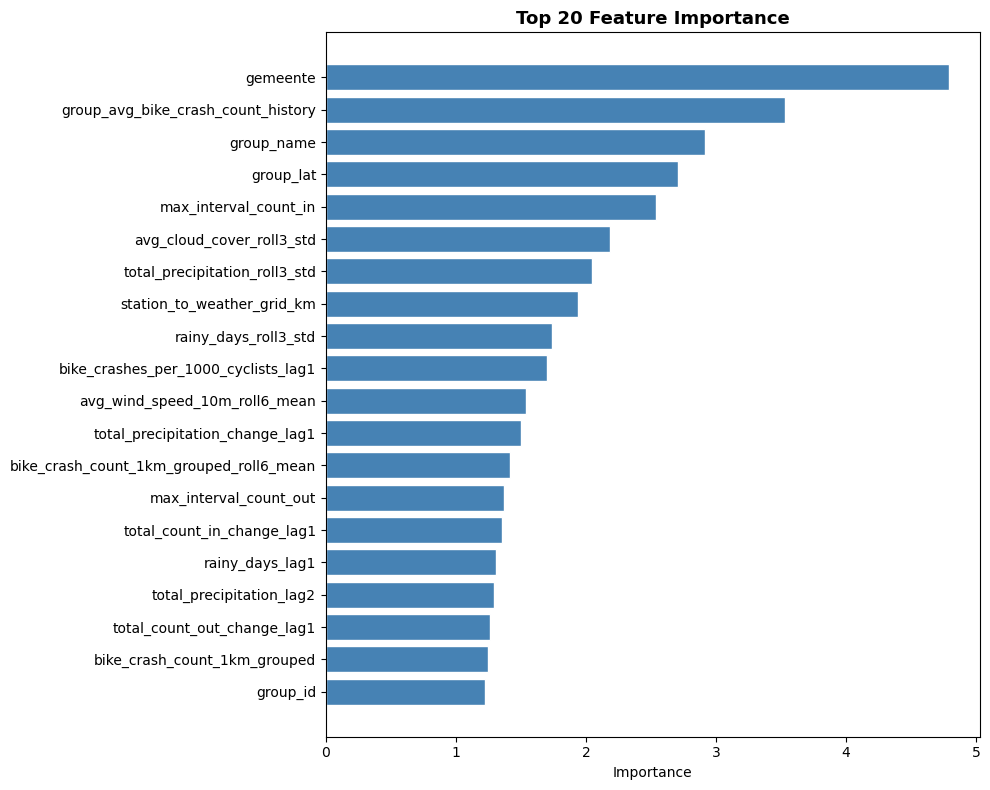

In [8]:
#Feature importance
importance_df = pd.read_csv(
    base_dir / "transformed_data" / "combined_station_groups_1km" / 
    "models" / "next_month_catboost_grouped_bike_1km_feature_importance.csv"
).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"], importance_df["importance"], color="steelblue", edgecolor="white")
plt.title("Top 20 Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()